# Cryptocurrency Market Analysis using yFinance

## Introduction
Cryptocurrency markets are highly volatile and attract investors worldwide.
This notebook performs exploratory data analysis (EDA) on major cryptocurrencies including Bitcoin, Ethereum, Binance Coin, Solana, and XRP.
The goal is to understand historical price trends, daily returns, and comparative performance of these digital assets.

#### Import Required Libraries

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

#### Download Cryptocurrency Data

In [8]:
crypto_list = ['BTC-USD','ETH-USD','BNB-USD','SOL-USD','XRP-USD']

crypto_data = yf.download(crypto_list,
                          start='2017-01-01',
                          end='2024-01-01')

[*********************100%***********************]  5 of 5 completed


#### Extract Closing Prices

In [10]:
close_prices = crypto_data['Close']

# Remove missing values
close_prices = close_prices.dropna()

close_prices.head()

Ticker,BNB-USD,BTC-USD,ETH-USD,SOL-USD,XRP-USD
Date,,,,,
2020-04-10,13.737724,6865.493164,158.412445,0.951054,0.187464
2020-04-11,13.804288,6859.083008,158.216019,0.776819,0.188063
2020-04-12,14.375111,6971.091797,161.142426,0.882507,0.190135
2020-04-13,15.034427,6845.037598,156.279556,0.777832,0.187732
2020-04-14,15.525076,6842.427734,157.596390,0.661925,0.185335


#### Dataset Overview

In [5]:
close_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1361 entries, 2020-04-10 to 2023-12-31
Freq: D
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BNB-USD  1361 non-null   float64
 1   BTC-USD  1361 non-null   float64
 2   ETH-USD  1361 non-null   float64
 3   SOL-USD  1361 non-null   float64
 4   XRP-USD  1361 non-null   float64
dtypes: float64(5)
memory usage: 63.8 KB


In [6]:
close_prices.describe()

Ticker,BNB-USD,BTC-USD,ETH-USD,SOL-USD,XRP-USD
count,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000
mean,264.434940,30414.193072,1828.907006,45.211834,0.561070
std,159.191858,14530.483568,1063.869235,53.976904,0.299360
min,13.737724,6642.109863,153.286896,0.515273,0.175870
25%,212.282837,19345.121094,1224.197144,12.851014,0.350861
50%,277.576935,28454.978516,1765.382690,24.613052,0.488716
75%,344.181763,41077.996094,2358.731934,46.890987,0.712568
max,675.684082,67566.828125,4812.087402,258.934326,1.839236


#### Visualizing Closing Price Trends

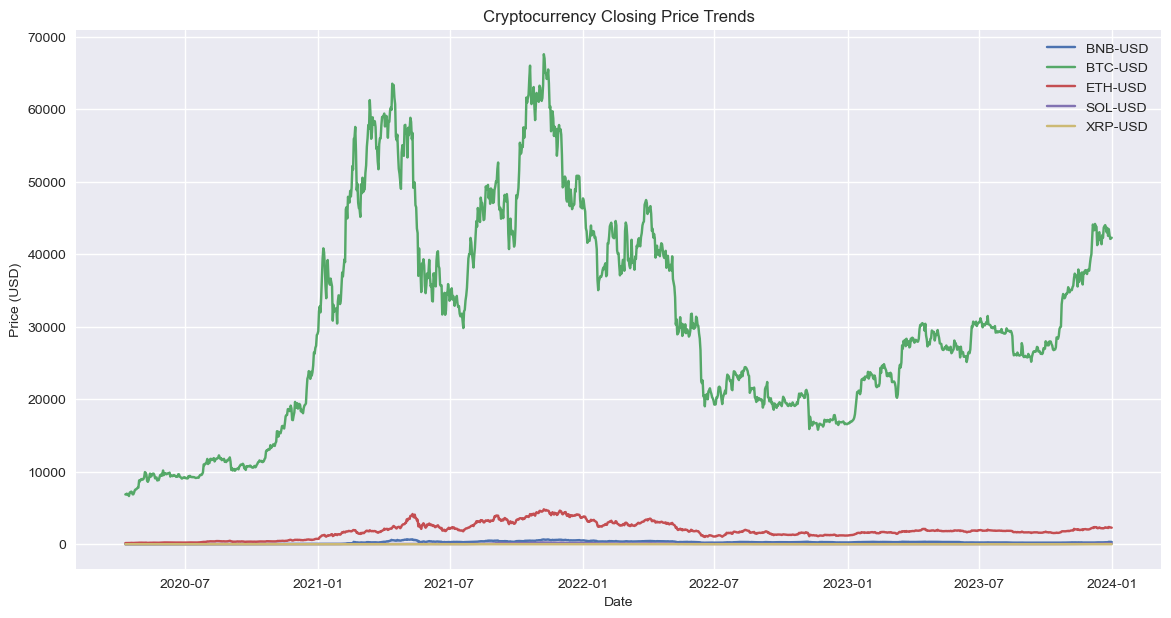

In [11]:
plt.figure(figsize=(14,7))

for crypto in close_prices.columns:
    plt.plot(close_prices[crypto], label=crypto)

plt.title("Cryptocurrency Closing Price Trends")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

#### Individual Cryptocurrency Price Trends

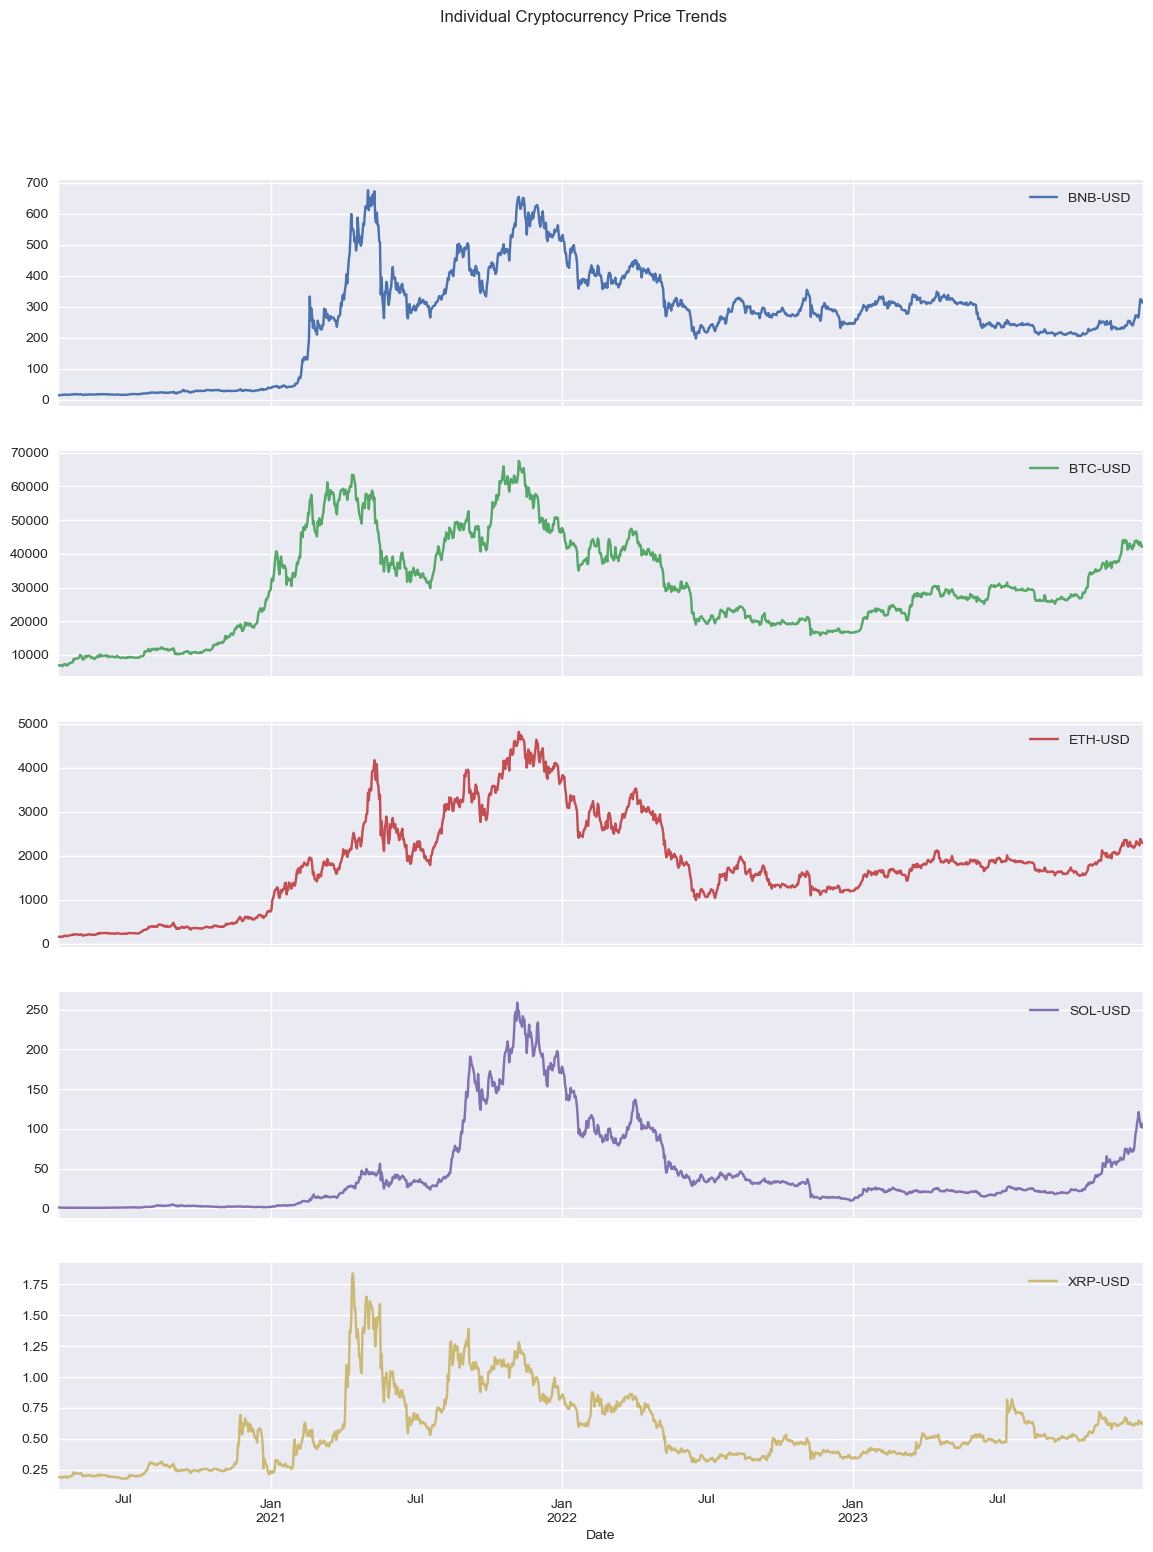

In [15]:
close_prices.plot(subplots=True,
                  figsize=(14,17),
                  title="Individual Cryptocurrency Price Trends")

plt.show()

#### Daily Returns Calculation

In [16]:
daily_returns = close_prices.pct_change()

daily_returns.head()

Ticker,BNB-USD,BTC-USD,ETH-USD,SOL-USD,XRP-USD
Date,,,,,
2020-04-10,NaN,NaN,NaN,NaN,NaN
2020-04-11,0.004845,-0.000934,-0.001240,-0.183202,0.003195
2020-04-12,0.041351,0.016330,0.018496,0.136052,0.011018
2020-04-13,0.045865,-0.018082,-0.030177,-0.118611,-0.012638
2020-04-14,0.032635,-0.000381,0.008426,-0.149013,-0.012768


#### Daily Returns Visualization

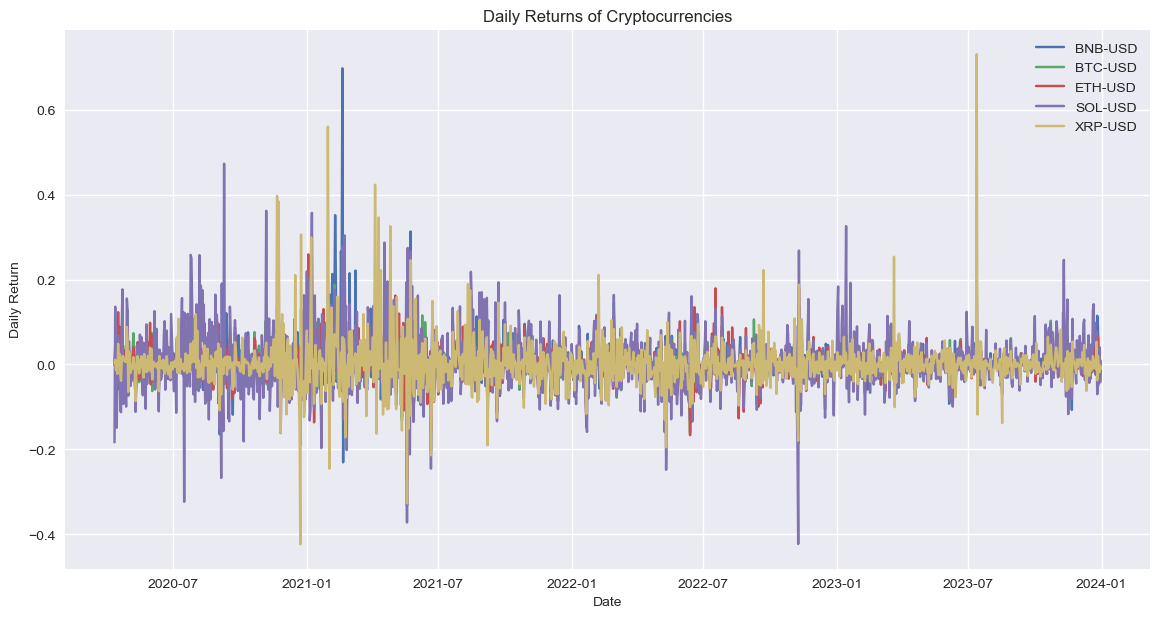

In [17]:
plt.figure(figsize=(14,7))

for crypto in daily_returns.columns:
    plt.plot(daily_returns[crypto], label=crypto)

plt.title("Daily Returns of Cryptocurrencies")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()

plt.show()

#### Distribution of Returns

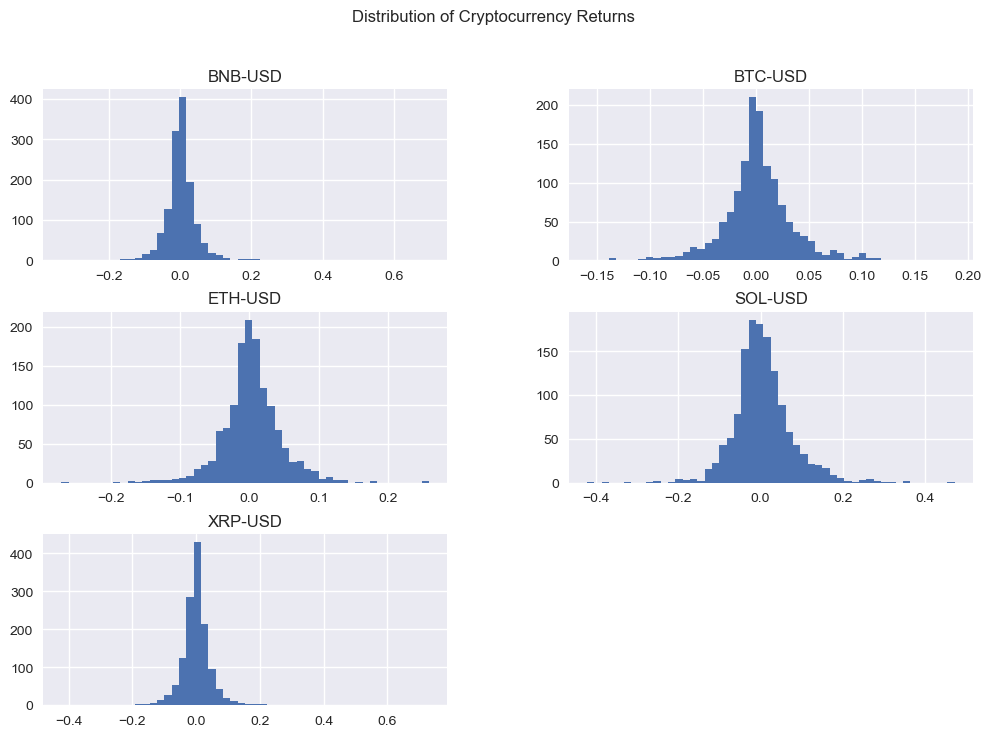

In [18]:
daily_returns.hist(bins=50,
                   figsize=(12,8))

plt.suptitle("Distribution of Cryptocurrency Returns")
plt.show()

#### Correlation Between Cryptocurrencies

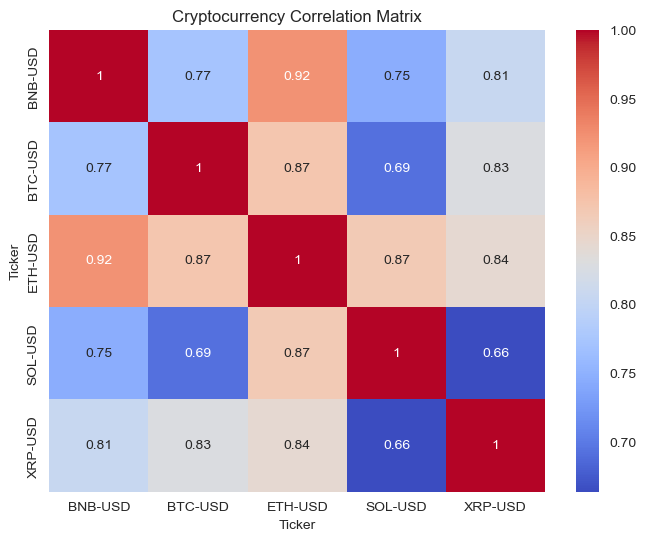

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(close_prices.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Cryptocurrency Correlation Matrix")

plt.show()

#### Moving Average Analysis

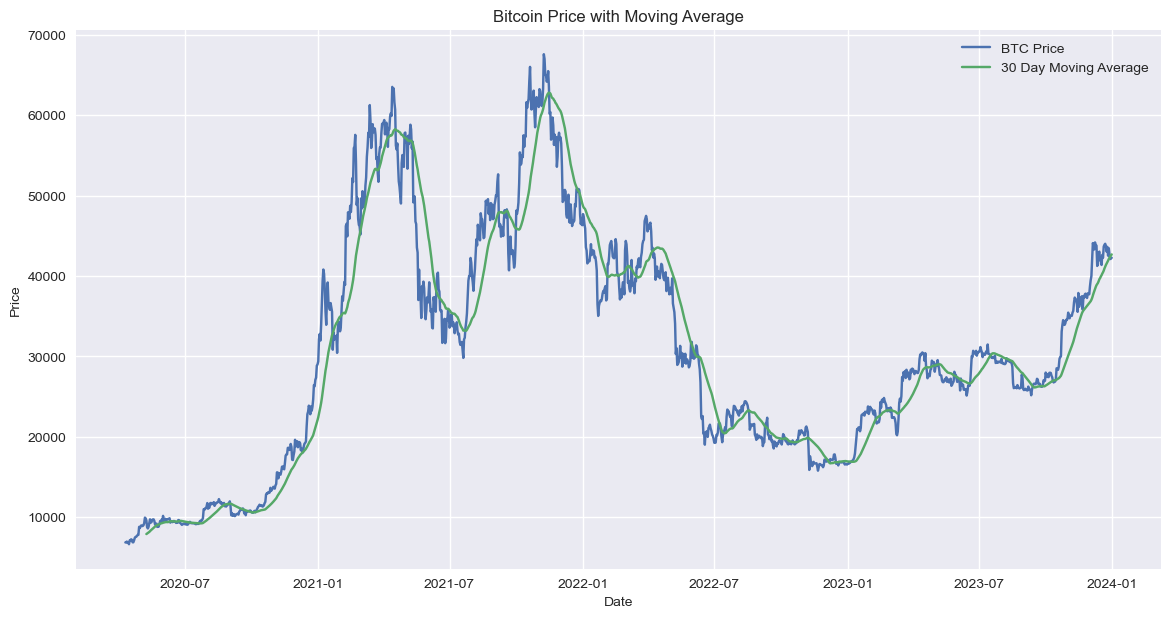

In [22]:
rolling_mean = close_prices.rolling(window=30).mean()

plt.figure(figsize=(14,7))

plt.plot(close_prices['BTC-USD'], label='BTC Price')
plt.plot(rolling_mean['BTC-USD'], label='30 Day Moving Average')

plt.title("Bitcoin Price with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

#### Key Insights
Bitcoin shows the strongest long-term growth trend among cryptocurrencies.

Ethereum closely follows Bitcoin with strong price movements.

Solana and BNB show high volatility compared to other coins.

Cryptocurrency returns are highly correlated, indicating market dependency.

## Conclusion
This exploratory analysis highlighted major trends in cryptocurrency markets.
Bitcoin and Ethereum dominate the market with consistent long-term growth, while altcoins like Solana and BNB exhibit higher volatility.
Understanding these trends is important before building machine learning models for cryptocurrency price prediction.